# Exploratory Data Analysis & Preprocessing
This notebook contains:
1. Data loading and initial exploration.
2. Handling class imbalance via stratified downsampling (preserving all fraud cases).
3. Visual analysis of features, transaction types, amounts, and steps.
4. Feature engineering of balance discrepancy metrics.
5. Execution of the preprocessing pipeline (One-Hot Encoding, scaling, and splitting).
6. Verification of the processed splits.

In [1]:
import os
import sys
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure path to import local modules from src
sys.path.insert(0, os.path.abspath(".."))

from src.preprocessing.data_loader import load_data, validate_data
from src.preprocessing.feature_scaler import scale_features
from src.preprocessing.data_splitter import split_data
from src.utils import RANDOM_STATE, DATA_RAW_PATH, DATA_PROCESSED_DIR, get_project_root, set_seeds

# Set seeds for reproducibility
set_seeds(RANDOM_STATE)

# Matplotlib & Seaborn styling
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

## 1. Load Data
We first load the original raw PaySim dataset to understand its shape and structure.

In [2]:
raw_path = os.path.join(get_project_root(), DATA_RAW_PATH)
print(f"Loading raw dataset from: {DATA_RAW_PATH}")
df_raw = pd.read_csv(raw_path)
print(f"Raw data shape: {df_raw.shape}")

Loading raw dataset from: data/raw/paysim.csv


Raw data shape: (6362620, 11)


## 2. Basic Info & Missing Values
Let's inspect data types, basic summary statistics, and missing values in the raw dataset.

In [3]:
print("=== Columns and dtypes ===")
print(df_raw.info())

print("\n=== Missing values per column ===")
print(df_raw.isnull().sum())

=== Columns and dtypes ===
<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 534.0 MB
None

=== Missing values per column ===


step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


## 3. Target Distribution (isFraud)
We analyze the extreme imbalance in the target variable `isFraud`.

isFraud
0    6354407
1       8213
Name: count, dtype: int64


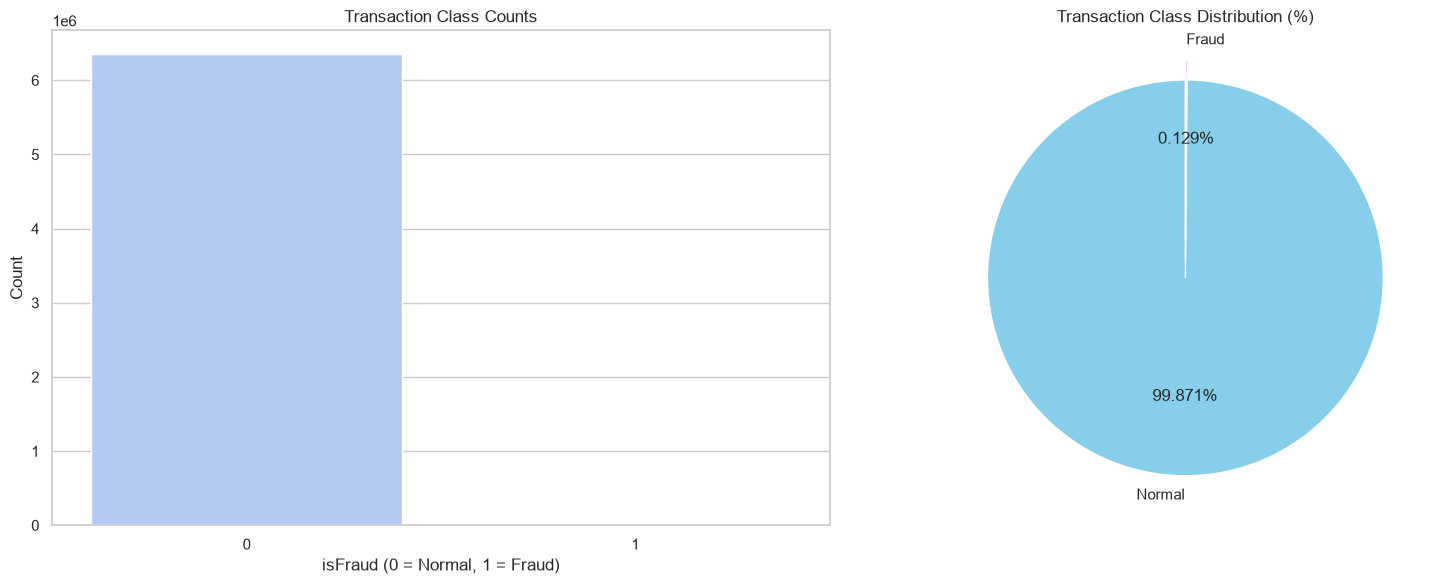

In [4]:
fraud_counts = df_raw["isFraud"].value_counts()
print(fraud_counts)

# Visualizing target distribution
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
sns.barplot(x=fraud_counts.index, y=fraud_counts.values, ax=ax[0], hue=fraud_counts.index, legend=False, palette="coolwarm")
ax[0].set_title("Transaction Class Counts")
ax[0].set_xlabel("isFraud (0 = Normal, 1 = Fraud)")
ax[0].set_ylabel("Count")

# Pie chart
ax[1].pie(fraud_counts, labels=["Normal", "Fraud"], autopct="%1.3f%%", colors=["skyblue", "red"], startangle=90, explode=(0, 0.1))
ax[1].set_title("Transaction Class Distribution (%)")

plt.tight_layout()
plt.show()

## 4. Transaction Types Analysis
Let's see what transaction types exist and which types are involved in fraud.

isFraud         0     1
type                   
CASH_IN   1399284     0
CASH_OUT  2233384  4116
DEBIT       41432     0
PAYMENT   2151495     0
TRANSFER   528812  4097


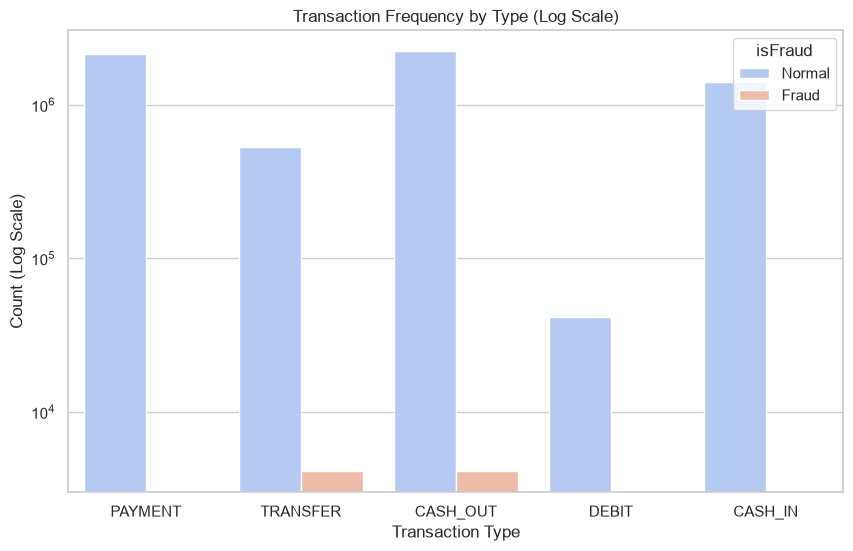

In [5]:
# Group by type and isFraud
type_fraud = df_raw.groupby(["type", "isFraud"]).size().unstack(fill_value=0)
print(type_fraud)

# Bar plot of transaction count by type
plt.figure(figsize=(10, 6))
sns.countplot(data=df_raw, x="type", hue="isFraud", palette="coolwarm")
plt.yscale("log")
plt.title("Transaction Frequency by Type (Log Scale)")
plt.xlabel("Transaction Type")
plt.ylabel("Count (Log Scale)")
plt.legend(title="isFraud", labels=["Normal", "Fraud"])
plt.show()

## 5. Stratified Downsampling
To prevent Out-Of-Memory (OOM) errors and make training efficient, we filter for `TRANSFER` and `CASH_OUT`, and perform stratified downsampling to ~200,000 rows while preserving all 8,213 fraud transactions.

In [6]:
df_downsampled = load_data(raw_path)
stats = validate_data(df_downsampled)
print("Downsampled Dataset Stats:")
for k, v in stats.items():
    print(f"  {k}: {v}")

Downsampled Dataset Stats:
  shape: (200000, 11)
  n_fraud: 8213
  n_normal: 191787
  fraud_ratio: 0.041065
  missing_values: 0


## 6. Visualizing Features on Downsampled Dataset
We analyze distributions of the key numerical features for normal vs. fraud transactions on the downsampled dataset.

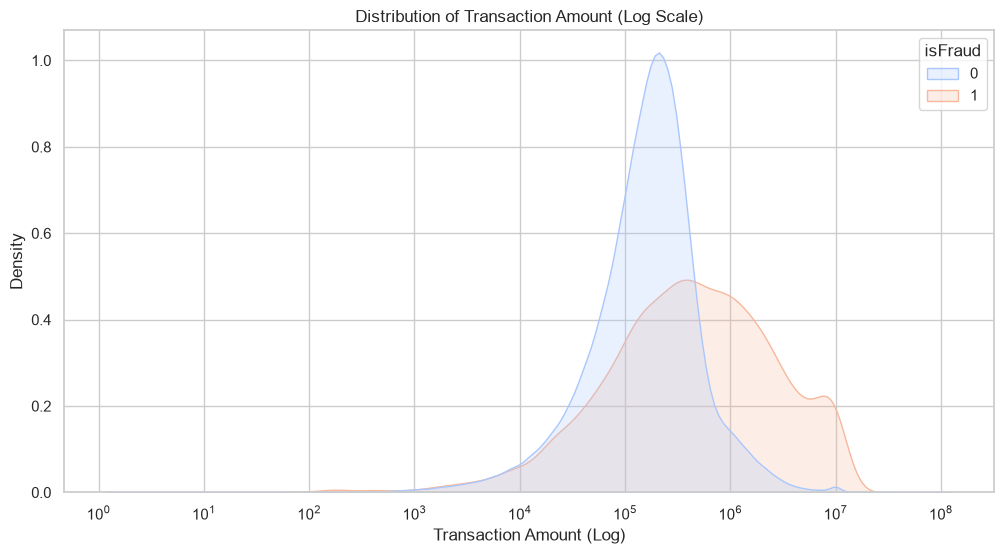

In [7]:
# 1. Amount distribution
plt.figure(figsize=(12, 6))
sns.kdeplot(data=df_downsampled[df_downsampled["amount"] > 0], x="amount", hue="isFraud", fill=True, common_norm=False, palette="coolwarm", log_scale=True)
plt.title("Distribution of Transaction Amount (Log Scale)")
plt.xlabel("Transaction Amount (Log)")
plt.ylabel("Density")
plt.show()

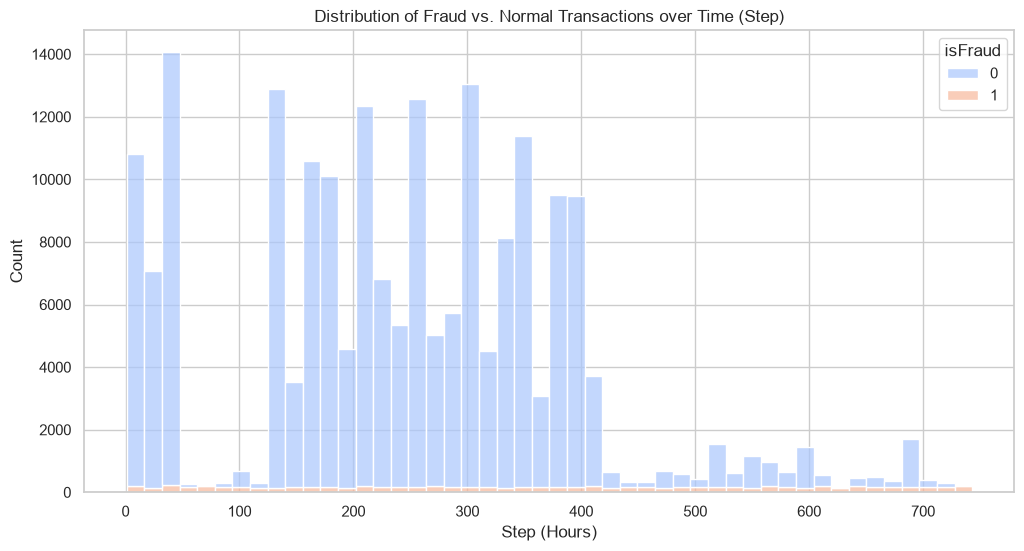

In [8]:
# 2. Time (step) analysis
plt.figure(figsize=(12, 6))
sns.histplot(data=df_downsampled, x="step", hue="isFraud", multiple="stack", bins=48, palette="coolwarm", alpha=0.7)
plt.title("Distribution of Fraud vs. Normal Transactions over Time (Step)")
plt.xlabel("Step (Hours)")
plt.ylabel("Count")
plt.show()

## 7. Balance Analysis and Feature Engineering
Let's see if there are balance discrepancies (errors in original and destination balances) and how they correlate with fraud.
We define:
`errorBalanceOrig = oldbalanceOrig - amount - newbalanceOrig`
`errorBalanceDest = oldbalanceDest + amount - newbalanceDest`

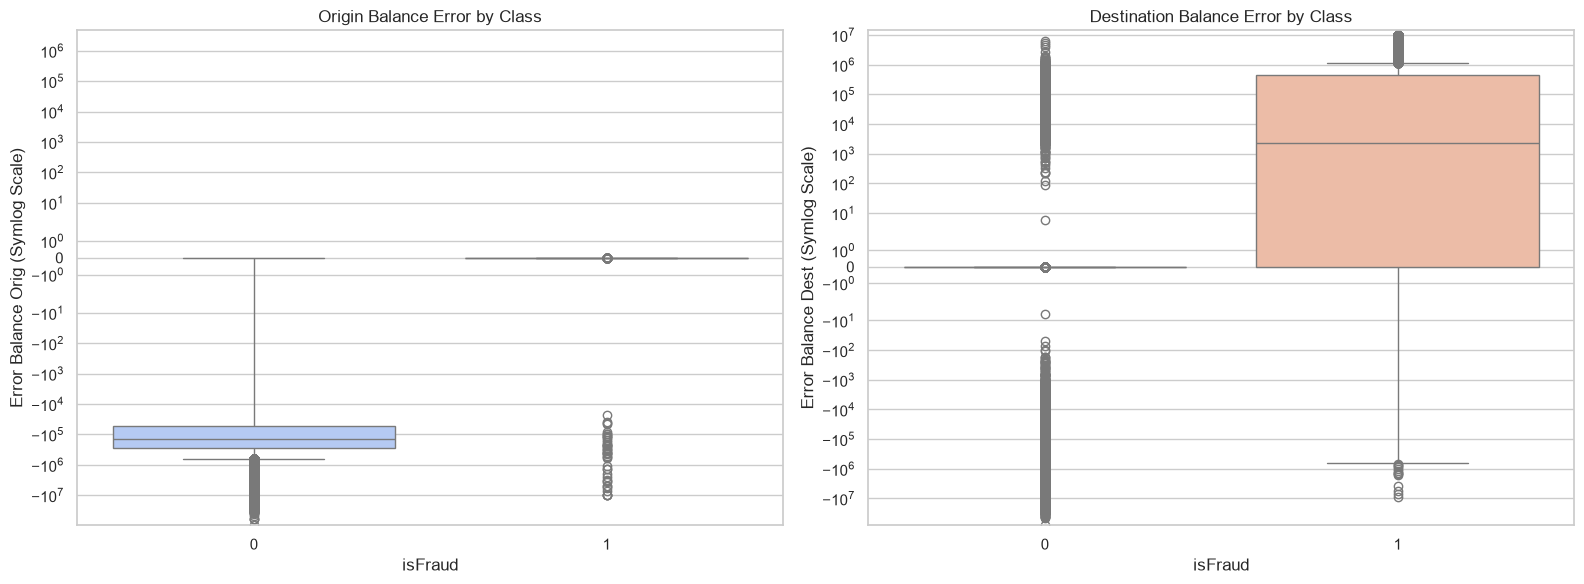

In [9]:
df_eng = df_downsampled.copy()
df_eng["errorBalanceOrig"] = df_eng["oldbalanceOrg"] - df_eng["amount"] - df_eng["newbalanceOrig"]
df_eng["errorBalanceDest"] = df_eng["oldbalanceDest"] + df_eng["amount"] - df_eng["newbalanceDest"]

# Plot distributions of balance errors
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=df_eng, x="isFraud", y="errorBalanceOrig", ax=ax[0], hue="isFraud", legend=False, palette="coolwarm")
ax[0].set_title("Origin Balance Error by Class")
ax[0].set_yscale("symlog")
ax[0].set_ylabel("Error Balance Orig (Symlog Scale)")

sns.boxplot(data=df_eng, x="isFraud", y="errorBalanceDest", ax=ax[1], hue="isFraud", legend=False, palette="coolwarm")
ax[1].set_title("Destination Balance Error by Class")
ax[1].set_yscale("symlog")
ax[1].set_ylabel("Error Balance Dest (Symlog Scale)")

plt.tight_layout()
plt.show()

## 8. Correlation Matrix Heatmap
We encode `type` (One-Hot Encoding) and check the correlation matrix of numerical features and engineered features on the downsampled dataset.

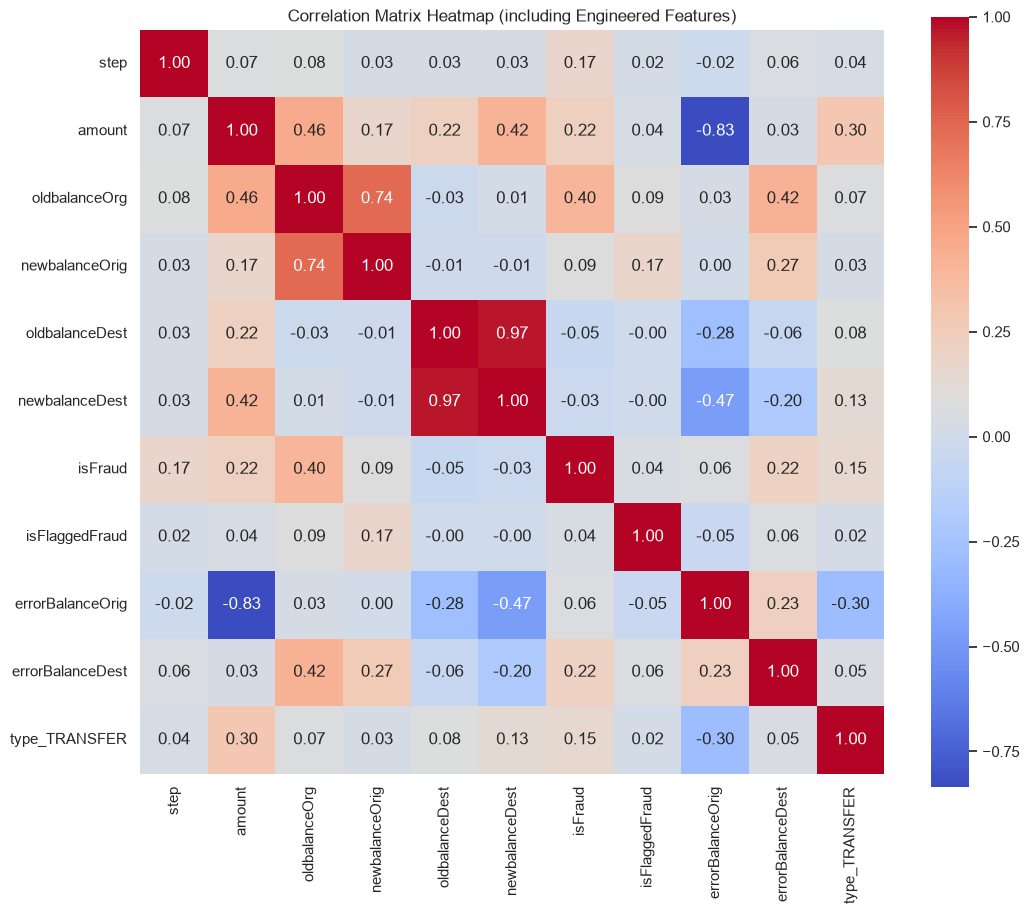

In [10]:
# One-hot encoding type column for correlation computation
df_corr = pd.get_dummies(df_eng.drop(columns=["nameOrig", "nameDest"]), columns=["type"], drop_first=True)

# Compute correlations
corr_matrix = df_corr.corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, square=True)
plt.title("Correlation Matrix Heatmap (including Engineered Features)")
plt.show()

## 9. Preprocessing Pipeline Execution
We split the data and apply the complete scaling, encoding, and engineering pipeline using our library modules.

In [11]:
# 1. Split data (without saving, we will save processed after scaling)
X_train, X_test, y_train, y_test = split_data(df_downsampled, save=False)

# 2. Scale and Encode
X_train_scaled, X_test_scaled, scaler = scale_features(X_train, X_test)

# 3. Save splits
processed_dir = os.path.join(get_project_root(), DATA_PROCESSED_DIR)
os.makedirs(processed_dir, exist_ok=True)
for name, obj in [
    ("X_train", X_train_scaled),
    ("X_test", X_test_scaled),
    ("y_train", y_train),
    ("y_test", y_test),
]:
    path = os.path.join(processed_dir, f"{name}.pkl")
    with open(path, "wb") as f:
        pickle.dump(obj, f)
    print(f"Saved processed file: {DATA_PROCESSED_DIR}/{name}.pkl")

# 4. Save fitted scaler
models_dir = os.path.join(get_project_root(), "models")
os.makedirs(models_dir, exist_ok=True)
scaler_path = os.path.join(models_dir, "scaler.pkl")
with open(scaler_path, "wb") as f:
    pickle.dump(scaler, f)
print("Saved fitted scaler to: models/scaler.pkl")

Saved processed file: data/processed/X_train.pkl
Saved processed file: data/processed/X_test.pkl
Saved processed file: data/processed/y_train.pkl
Saved processed file: data/processed/y_test.pkl
Saved fitted scaler to: models/scaler.pkl


## 10. Verify Splits
We verify that the training and testing sets maintain the same class ratios and shapes as required by the success criteria.

In [12]:
print(f"X_train shape: {X_train_scaled.shape} (Expected: (160000, 9))")
print(f"X_test shape: {X_test_scaled.shape} (Expected: (40000, 9))")
print(f"y_train fraud ratio: {y_train.mean():.6f} (Expected: ~0.041065)")
print(f"y_test fraud ratio: {y_test.mean():.6f} (Expected: ~0.041065)")

# Verification assertions
assert X_train_scaled.shape == (160000, 9)
assert X_test_scaled.shape == (40000, 9)
assert abs(y_train.mean() - 0.041065) < 1e-4
assert abs(y_test.mean() - 0.041065) < 1e-4
print("All split verifications passed successfully!")

X_train shape: (160000, 9) (Expected: (160000, 9))
X_test shape: (40000, 9) (Expected: (40000, 9))
y_train fraud ratio: 0.041063 (Expected: ~0.041065)
y_test fraud ratio: 0.041075 (Expected: ~0.041065)
All split verifications passed successfully!


## 11. Key Observations & Conclusions
- **Class Imbalance:** Only 0.13% of transactions are fraudulent in the raw dataset. We resolved OOM constraints using stratified downsampling to ~200k rows (holding all 8,213 frauds).
- **Transaction Types:** Fraud occurs ONLY in `TRANSFER` and `CASH_OUT` transaction types.
- **Engineered Features:** Balance discrepancies (`errorBalanceOrig` and `errorBalanceDest`) have strong correlation and differences between fraud and normal transactions, making them excellent candidate features.
- **Pipeline:** Preprocessing (split, feature engineering, dummy encoding, scaling fit only on training) executes correctly and outputs consistent pickle data splits.